In [1]:
# =========================
# 1. Import libraries
# =========================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt

In [2]:
# =========================
# 2. Load dataset
# =========================
df = pd.read_csv("weather_hourly_darksky.csv")

df.head()

,visibility,windBearing,temperature,time,dewPoint,pressure,apparentTemperature,windSpeed,precipType,icon,humidity,summary
0,5.97,104,10.24,2011-11-11 00:00:00,8.86,1016.76,10.24,2.77,rain,partly-cloudy-night,0.91,Partly Cloudy
1,4.88,99,9.76,2011-11-11 01:00:00,8.83,1016.63,8.24,2.95,rain,partly-cloudy-night,0.94,Partly Cloudy
2,3.70,98,9.46,2011-11-11 02:00:00,8.79,1016.36,7.76,3.17,rain,partly-cloudy-night,0.96,Partly Cloudy
3,3.12,99,9.23,2011-11-11 03:00:00,8.63,1016.28,7.44,3.25,rain,fog,0.96,Foggy
4,1.85,111,9.26,2011-11-11 04:00:00,9.21,1015.98,7.24,3.70,rain,fog,1.00,Foggy


In [3]:
# =========================
# 3. Basic preprocessing
# =========================

# Drop rows with missing values
df = df.dropna()

# Convert time column if it exists
if 'time' in df.columns:
    df['time'] = pd.to_datetime(df['time'])
    df['hour'] = df['time'].dt.hour
    df['day'] = df['time'].dt.day
    df['month'] = df['time'].dt.month

df.head()

,visibility,windBearing,temperature,time,dewPoint,pressure,apparentTemperature,windSpeed,precipType,icon,humidity,summary,hour,day,month
0,5.97,104,10.24,2011-11-11 00:00:00,8.86,1016.76,10.24,2.77,rain,partly-cloudy-night,0.91,Partly Cloudy,0,11,11
1,4.88,99,9.76,2011-11-11 01:00:00,8.83,1016.63,8.24,2.95,rain,partly-cloudy-night,0.94,Partly Cloudy,1,11,11
2,3.70,98,9.46,2011-11-11 02:00:00,8.79,1016.36,7.76,3.17,rain,partly-cloudy-night,0.96,Partly Cloudy,2,11,11
3,3.12,99,9.23,2011-11-11 03:00:00,8.63,1016.28,7.44,3.25,rain,fog,0.96,Foggy,3,11,11
4,1.85,111,9.26,2011-11-11 04:00:00,9.21,1015.98,7.24,3.70,rain,fog,1.00,Foggy,4,11,11


In [7]:
# =========================
# 4. Select features and target
# =========================

# Change this depending on dataset columns
target = "temperature"   # <-- adjust if column name differs

# Drop non-numeric / target columns safely
X = df.drop(columns=[target], errors='ignore')
X = X.select_dtypes(include=[np.number])

y = df[target]

In [5]:
# =========================
# 5. Train-test split
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [6]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [8]:
et = ExtraTreesRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

et.fit(X_train, y_train)

et_pred = et.predict(X_test)

In [9]:
def evaluate_model(name, y_true, y_pred):
    print(f"📌 {name}")
    print("MAE:", mean_absolute_error(y_true, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))
    print("R2:", r2_score(y_true, y_pred))
    print("-" * 30)

evaluate_model("Random Forest", y_test, rf_pred)
evaluate_model("Extra Trees", y_test, et_pred)

📌 Random Forest
MAE: 0.01774065232805705
RMSE: 0.0455195794074413
R2: 0.9999386842357973
------------------------------
📌 Extra Trees
MAE: 0.017011722996927922
RMSE: 0.03678800019253447
R2: 0.9999599513367813
------------------------------


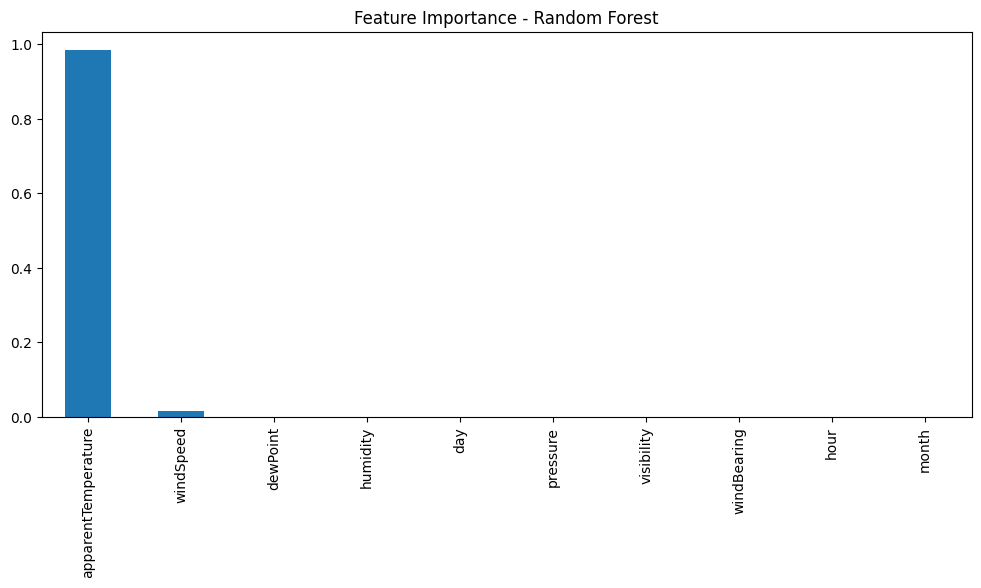

In [10]:
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).plot(kind='bar', figsize=(12,5))
plt.title("Feature Importance - Random Forest")
plt.show()

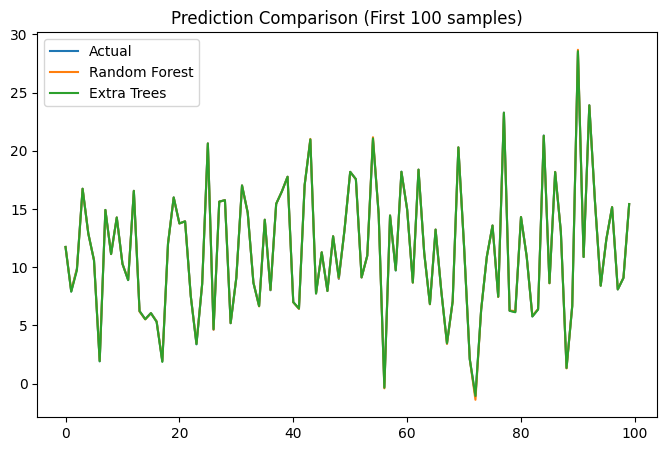

In [11]:
plt.figure(figsize=(8,5))
plt.plot(y_test.values[:100], label="Actual")
plt.plot(rf_pred[:100], label="Random Forest")
plt.plot(et_pred[:100], label="Extra Trees")
plt.legend()
plt.title("Prediction Comparison (First 100 samples)")
plt.show()